# Exploratory Data Analysis (EDA)

## Business Objective

ElderGuard Analytics aims to develop a non-invasive monitoring system capable of identifying elderly residents' activity levels using environmental sensor and indoor air quality data.

This analysis investigates the relationships between environmental conditions, gas sensor measurements, HVAC operations, lighting conditions, and resident activity behavior. The primary objective is to understand the dataset structure, identify potential data quality issues, discover meaningful patterns, and support the development of robust machine learning models for activity level prediction.

The findings from this EDA will guide preprocessing strategies, feature engineering decisions, model selection, and evaluation methodologies for the subsequent machine learning pipeline.

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

sns.set_style("whitegrid")

print("Libraries loaded successfully.")

Libraries loaded successfully.


## Dataset Loading

The dataset is stored in an SQLite database and contains environmental sensor readings collected from elderly residents’ homes. The data is loaded into a Pandas DataFrame for analysis.

In [2]:
conn = sqlite3.connect("../data/raw/gas_monitoring.db")

df = pd.read_sql_query(
    "SELECT * FROM gas_monitoring",
    conn
)

print("Dataset loaded successfully.")

Dataset loaded successfully.


## Initial Dataset Inspection

This section provides a high-level overview of the dataset structure, including the number of records, feature types, and sample observations.

In [3]:
df.head()

,Time of Day,Temperature,Humidity,CO2_InfraredSensor,CO2_ElectroChemicalSensor,MetalOxideSensor_Unit1,MetalOxideSensor_Unit2,MetalOxideSensor_Unit3,MetalOxideSensor_Unit4,CO_GasSensor,Session ID,HVAC Operation Mode,Ambient Light Level,Activity Level
0,morning,19.63,53.83,125.486389,571.089440,478.554958,735.850412,654.625253,565.051969,2.0,7241,off,very_dim,Low Activity
1,morning,292.81,53.69,126.343018,575.789501,491.955151,740.282738,655.734327,557.078486,1.0,7241,ventilation_only,bright,Low Activity
2,morning,19.62,54.25,126.560695,585.543111,505.560808,737.112906,649.962421,558.065196,1.0,7241,eco_mode,None,Low Activity
3,morning,20.10,50.48,113.504877,597.449961,515.142272,744.020651,676.150075,600.222210,NaN,7241,eco_mode,very_bright,High Activity
4,morning,19.89,48.42,92.766225,613.654875,535.664558,770.265441,720.274019,625.731124,1.0,7241,heating_active,moderate,LowActivity


In [4]:
print(f"Dataset Shape: {df.shape}")

Dataset Shape: (10000, 14)


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Time of Day                10000 non-null  object 
 1   Temperature                10000 non-null  float64
 2   Humidity                   8072 non-null   float64
 3   CO2_InfraredSensor         10000 non-null  float64
 4   CO2_ElectroChemicalSensor  10000 non-null  float64
 5   MetalOxideSensor_Unit1     10000 non-null  float64
 6   MetalOxideSensor_Unit2     8590 non-null   float64
 7   MetalOxideSensor_Unit3     10000 non-null  float64
 8   MetalOxideSensor_Unit4     10000 non-null  float64
 9   CO_GasSensor               9166 non-null   float64
 10  Session ID                 10000 non-null  int64  
 11  HVAC Operation Mode        10000 non-null  object 
 12  Ambient Light Level        8946 non-null   object 
 13  Activity Level             10000 non-null  obje

### Initial Dataset Observations

The dataset contains 10,000 records and 14 features representing environmental conditions, indoor air quality measurements, HVAC operations, lighting conditions, and resident activity levels.

The dataset includes a mixture of:
- Numerical sensor measurements (e.g., temperature, humidity, CO2 sensors, gas sensors)
- Contextual categorical features (e.g., Time of Day, HVAC Operation Mode, Ambient Light Level)
- A categorical target variable (`Activity Level`) for classification modeling.

Several features contain missing values:
- `Humidity`
- `MetalOxideSensor_Unit2`
- `CO_GasSensor`
- `Ambient Light Level`

This indicates that data quality assessment and missing value handling will be important preprocessing steps before model training.

The dataset structure appears suitable for supervised machine learning classification tasks, particularly for predicting resident activity levels based on environmental and air quality conditions.

## Data Quality Assessment

Data quality assessment is an important step in the machine learning pipeline as missing values, inconsistent records, and contaminated data may negatively impact model performance and reliability.

This section evaluates the completeness of the dataset by identifying missing values across all features.

In [6]:
df.isnull().sum()

Time of Day                     0
Temperature                     0
Humidity                     1928
CO2_InfraredSensor              0
CO2_ElectroChemicalSensor       0
MetalOxideSensor_Unit1          0
MetalOxideSensor_Unit2       1410
MetalOxideSensor_Unit3          0
MetalOxideSensor_Unit4          0
CO_GasSensor                  834
Session ID                      0
HVAC Operation Mode             0
Ambient Light Level          1054
Activity Level                  0
dtype: int64

### Missing Value Analysis

Several sensor and contextual features contain missing values. Understanding the proportion of missing data is important for determining appropriate preprocessing and imputation strategies.

High missingness may indicate:
- sensor malfunction
- transmission issues
- incomplete environmental recordings
- synthetic contamination within the dataset

The missing value percentages are calculated below for further assessment.

In [7]:
missing_percentage = (
    df.isnull().sum() / len(df)
) * 100

missing_percentage.sort_values(ascending=False)

Humidity                     19.28
MetalOxideSensor_Unit2       14.10
Ambient Light Level          10.54
CO_GasSensor                  8.34
Time of Day                   0.00
Temperature                   0.00
CO2_InfraredSensor            0.00
CO2_ElectroChemicalSensor     0.00
MetalOxideSensor_Unit1        0.00
MetalOxideSensor_Unit3        0.00
MetalOxideSensor_Unit4        0.00
Session ID                    0.00
HVAC Operation Mode           0.00
Activity Level                0.00
dtype: float64

### Missing Value Observations

Several features contain missing values, particularly:
- Humidity (19.28%)
- MetalOxideSensor_Unit2 (14.10%)
- Ambient Light Level (10.54%)
- CO_GasSensor (8.34%)

No feature exceeds 20% missingness, so feature removal is not necessary at this stage.

These missing values may indicate:
- intermittent sensor failures
- incomplete environmental recordings
- data contamination during collection

Appropriate imputation strategies will be required during preprocessing before model training.

## Missing Value Visualization

Visualizing missing data patterns helps identify the severity and distribution of incomplete records across the dataset.

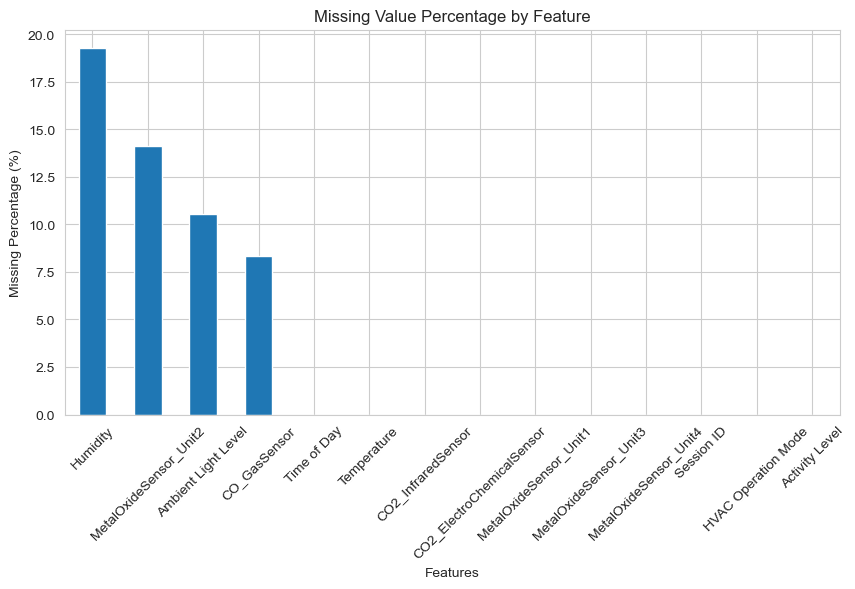

In [8]:
plt.figure(figsize=(10, 5))

missing_percentage.sort_values(ascending=False).plot(
    kind="bar"
)

plt.title("Missing Value Percentage by Feature")
plt.xlabel("Features")
plt.ylabel("Missing Percentage (%)")

plt.xticks(rotation=45)

plt.show()

## Duplicate Record Detection

Duplicate records can introduce bias into machine learning models and affect evaluation reliability.

This step checks whether duplicate observations exist within the dataset.

In [9]:
df.duplicated().sum()

171

### Duplicate Record Observations

The dataset contains 171 duplicate records.

Duplicate observations may:
- introduce bias into machine learning models
- artificially inflate model performance
- reduce dataset reliability

Since duplicate rows do not provide additional information, they will likely be removed during preprocessing to improve data quality and model generalization.

## Creating Processed Dataset

To preserve the integrity of the original dataset, a separate processed dataset is created for cleaning and preprocessing operations.

This allows comparison between raw and cleaned data throughout the analysis workflow.

In [10]:
df_processed = df.copy()

print("Processed dataset created successfully.")

Processed dataset created successfully.


In [ ]:
## Duplicate Removal

Duplicate records are removed to ensure

In [12]:
df_processed = df_processed.drop_duplicates()

print("Updated Processed Dataset Shape:", df_processed.shape)
print("Duplicates remaining:", df_processed.duplicated().sum())

Updated Processed Dataset Shape: (9829, 14)
Duplicates remaining: 0


## Missing Value Handling

Missing values are handled using imputation techniques to preserve important sensor information while improving dataset completeness.

For numerical sensor measurements, median imputation is preferred because it is more robust to outliers compared to mean imputation.

For categorical features, mode imputation is used to replace missing values with the most frequent category.

In [13]:
df_processed.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9829 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Time of Day                9829 non-null   object 
 1   Temperature                9829 non-null   float64
 2   Humidity                   7912 non-null   float64
 3   CO2_InfraredSensor         9829 non-null   float64
 4   CO2_ElectroChemicalSensor  9829 non-null   float64
 5   MetalOxideSensor_Unit1     9829 non-null   float64
 6   MetalOxideSensor_Unit2     8423 non-null   float64
 7   MetalOxideSensor_Unit3     9829 non-null   float64
 8   MetalOxideSensor_Unit4     9829 non-null   float64
 9   CO_GasSensor               8999 non-null   float64
 10  Session ID                 9829 non-null   int64  
 11  HVAC Operation Mode        9829 non-null   object 
 12  Ambient Light Level        8777 non-null   object 
 13  Activity Level             9829 non-null   object 
dt

### Imputation Strategy

The dataset contains both numerical and categorical missing values.

Imputation strategies:
- Numerical sensor features → median imputation
- Categorical features → mode imputation

Median imputation is preferred for sensor readings because environmental measurements may contain outliers or skewed distributions.

In [14]:
numerical_columns = [
    "Humidity",
    "MetalOxideSensor_Unit2",
    "CO_GasSensor"
]

for column in numerical_columns:
    median_value = df_processed[column].median()
    df_processed[column] = df_processed[column].fillna(median_value)

print("Numerical missing values handled successfully.")

Numerical missing values handled successfully.


In [15]:
categorical_columns = [
    "Ambient Light Level"
]

for column in categorical_columns:
    mode_value = df_processed[column].mode()[0]
    df_processed[column] = df_processed[column].fillna(mode_value)

print("Categorical missing values handled successfully.")

Categorical missing values handled successfully.


In [16]:
df_processed.isnull().sum()

Time of Day                  0
Temperature                  0
Humidity                     0
CO2_InfraredSensor           0
CO2_ElectroChemicalSensor    0
MetalOxideSensor_Unit1       0
MetalOxideSensor_Unit2       0
MetalOxideSensor_Unit3       0
MetalOxideSensor_Unit4       0
CO_GasSensor                 0
Session ID                   0
HVAC Operation Mode          0
Ambient Light Level          0
Activity Level               0
dtype: int64

### Missing Value Handling Summary

All missing values in the processed dataset have been successfully handled using:
- median imputation for numerical sensor features
- mode imputation for categorical features

The processed dataset is now complete and ready for deeper exploratory analysis and feature relationship investigation.

# Univariate Analysis

Univariate analysis examines the distribution and characteristics of individual variables independently.

This helps identify:
- data distribution patterns
- skewness
- unusual values
- class imbalance
- potential outliers

## Target Variable Analysis

The target variable, `Activity Level`, represents the predicted activity state within the smart environment.

Analyzing its distribution helps identify potential class imbalance issues that may affect machine learning model performance.

In [17]:
df_processed["Activity Level"].value_counts()

Activity Level
Low Activity         5146
Moderate Activity    2765
High Activity        1070
ModerateActivity      325
Low_Activity          285
LowActivity           238
Name: count, dtype: int64

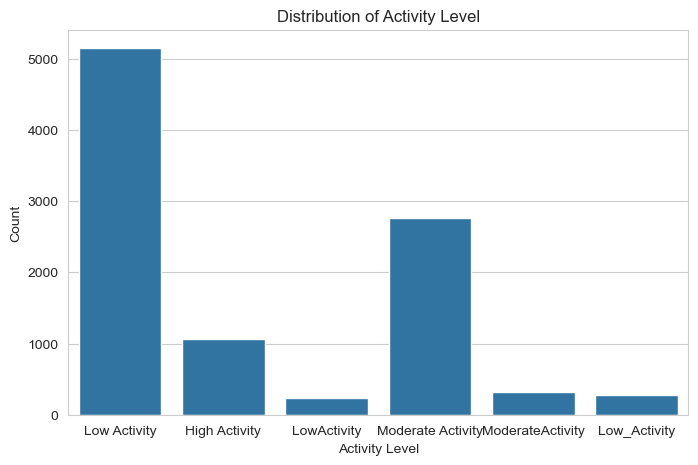

In [18]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df_processed,
    x="Activity Level"
)

plt.title("Distribution of Activity Level")
plt.xlabel("Activity Level")
plt.ylabel("Count")

plt.show()

### Target Variable Observations

The target variable contains inconsistent category labels representing the same activity classes.

Examples:
- `Low Activity`, `LowActivity`, and `Low_Activity`
- `Moderate Activity` and `ModerateActivity`

These inconsistencies may negatively affect model training because machine learning algorithms treat them as separate classes.

Therefore, category standardization is required before modeling.